# BERT

In [ ]:
# Загружаем библиотеки
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from pylab import rcParams
from IPython import display
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap
from nltk.tokenize import word_tokenize

import transformers
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
import torch
from torch.optim import AdamW
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

![alt text](https://hsto.org/webt/uh/cd/qv/uhcdqv--w2t4i8srv9rtzjgk9ac.png)

<div class="alert alert-info">

**Цель занятия:**

- Посмотреть как работает bpe токенизатор
- Выполнить fine-tune BERT
- Разобраться с логированием во время обучения


# Byte-pair-encoding

Простой алгоритм сжатия данных, [впервые представленный](https://www.derczynski.com/papers/archive/BPE_Gage.pdf) в 1994 году. Позднее он был повторно представлен для NLP для задачи сегментации слов в [этой статье](https://arxiv.org/pdf/1508.07909.pdf). **BPE** позволяет представлять словарь через словарь фиксированного размера последовательностей символов переменной длины.

![alt text](https://alexanderdyakonov.files.wordpress.com/2019/11/bpe.jpg)

Source: [Subword Tokenization](https://dyakonov.org/2019/11/29/%D1%82%D0%BE%D0%BA%D0%B5%D0%BD%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F-%D0%BD%D0%B0-%D0%BF%D0%BE%D0%B4%D1%81%D0%BB%D0%BE%D0%B2%D0%B0-subword-tokenization/)

## Реализация

Теперь давайте рассмотрим реализацию алгоритма **BPE**. Это не будет оптимизированная версия, которую вы сможете использовать на большом корпусе; мы просто хотим показать вам код, чтобы вы могли немного лучше понять сам алгоритм.

Сначала нам нужен корпус, поэтому давайте создадим простой с несколькими предложениями:

In [ ]:
corpus = [
    "This is the Sirius Course",
    "This chapter is about tokenization",
    "This section shows several tokenizer algorithms",
    "Hopefully you will be able to understand how they are trained and generate tokens",
]

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
# Далее нам необходимо сделать претокенизацию - разделить текст на слова и посчитать частоту каждого слова

word_freqs = defaultdict(int)

for text in corpus:
    new_words = [word for word in word_tokenize(text)]
    for word in new_words:
        word_freqs[word] += 1

print(word_freqs)

defaultdict(<class 'int'>, {'This': 3, 'is': 2, 'the': 1, 'Sirius': 1, 'Course': 1, 'chapter': 1, 'about': 1, 'tokenization': 1, 'section': 1, 'shows': 1, 'several': 1, 'tokenizer': 1, 'algorithms': 1, 'Hopefully': 1, 'you': 1, 'will': 1, 'be': 1, 'able': 1, 'to': 1, 'understand': 1, 'how': 1, 'they': 1, 'are': 1, 'trained': 1, 'and': 1, 'generate': 1, 'tokens': 1})


In [ ]:
# Следующим шагом составим базовый словарь, состоящий из всех символов нашего корпуса

alphabet = []

for word in word_freqs.keys():
    for letter in word:
        if letter not in alphabet:
            alphabet.append(letter)

alphabet.sort()

print(alphabet)

['C', 'H', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z']


In [ ]:
# Также добавляем специальные символы

vocab = ["<|beginoftext|>", "<|endoftext|>"] + alphabet.copy()

In [ ]:
# Разделяем каждое слово на буквы

splits = {word: [c for c in word] for word in word_freqs.keys()}

In [ ]:
# Теперь напишем функцию которая считает частоту каждой пары

def compute_pair_freqs(splits):
    pair_freqs = defaultdict(int)
    for word, freq in word_freqs.items():
        split = splits[word]
        if len(split) == 1:
            continue
        for i in range(len(split) - 1):
            pair = (split[i], split[i + 1])
            pair_freqs[pair] += freq
    return pair_freqs


In [ ]:
pair_freqs = compute_pair_freqs(splits)

for i, key in enumerate(pair_freqs.keys()):
    print(f"{key}: {pair_freqs[key]}")
    # if i >= 5:
        # break


('T', 'h'): 3
('h', 'i'): 3
('i', 's'): 5
('t', 'h'): 3
('h', 'e'): 2
('S', 'i'): 1
('i', 'r'): 1
('r', 'i'): 2
('i', 'u'): 1
('u', 's'): 1
('C', 'o'): 1
('o', 'u'): 3
('u', 'r'): 1
('r', 's'): 2
('s', 'e'): 3
('c', 'h'): 1
('h', 'a'): 1
('a', 'p'): 1
('p', 't'): 1
('t', 'e'): 2
('e', 'r'): 5
('a', 'b'): 2
('b', 'o'): 1
('u', 't'): 1
('t', 'o'): 4
('o', 'k'): 3
('k', 'e'): 3
('e', 'n'): 4
('n', 'i'): 2
('i', 'z'): 2
('z', 'a'): 1
('a', 't'): 2
('t', 'i'): 2
('i', 'o'): 2
('o', 'n'): 2
('e', 'c'): 1
('c', 't'): 1
('s', 'h'): 1
('h', 'o'): 2
('o', 'w'): 2
('w', 's'): 1
('e', 'v'): 1
('v', 'e'): 1
('r', 'a'): 3
('a', 'l'): 2
('z', 'e'): 1
('l', 'g'): 1
('g', 'o'): 1
('o', 'r'): 1
('i', 't'): 1
('h', 'm'): 1
('m', 's'): 1
('H', 'o'): 1
('o', 'p'): 1
('p', 'e'): 1
('e', 'f'): 1
('f', 'u'): 1
('u', 'l'): 1
('l', 'l'): 2
('l', 'y'): 1
('y', 'o'): 1
('w', 'i'): 1
('i', 'l'): 1
('b', 'e'): 1
('b', 'l'): 1
('l', 'e'): 1
('u', 'n'): 1
('n', 'd'): 3
('d', 'e'): 1
('s', 't'): 1
('t', 'a'): 1
('a', 

In [ ]:
# Найдем часто встречающуюся пару

best_pair = ""
max_freq = None

for pair, freq in pair_freqs.items():
    if max_freq is None or max_freq < freq:
        best_pair = pair
        max_freq = freq

print(best_pair, max_freq)

('i', 's') 5


In [ ]:
# Добавим ее в словарь

merges = {('i', 's'): "is"}
vocab.append("is")

In [ ]:
# Далее нам необходимо применить эту функцию к словарю splits

def merge_pair(a, b, splits):
    for word in word_freqs:
        split = splits[word]
        if len(split) == 1:
            continue

        i = 0
        while i < len(split) - 1:
            if split[i] == a and split[i + 1] == b:
                split = split[:i] + [a + b] + split[i + 2 :]
            else:
                i += 1
        splits[word] = split
    return splits


In [ ]:
# Посмотрим что получилось

splits = merge_pair("i", "s", splits)
print(splits["This"])

['T', 'h', 'is']


In [ ]:
splits

{'This': ['T', 'h', 'is'],
 'is': ['is'],
 'the': ['t', 'h', 'e'],
 'Sirius': ['S', 'i', 'r', 'i', 'u', 's'],
 'Course': ['C', 'o', 'u', 'r', 's', 'e'],
 'chapter': ['c', 'h', 'a', 'p', 't', 'e', 'r'],
 'about': ['a', 'b', 'o', 'u', 't'],
 'tokenization': ['t', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 't', 'i', 'o', 'n'],
 'section': ['s', 'e', 'c', 't', 'i', 'o', 'n'],
 'shows': ['s', 'h', 'o', 'w', 's'],
 'several': ['s', 'e', 'v', 'e', 'r', 'a', 'l'],
 'tokenizer': ['t', 'o', 'k', 'e', 'n', 'i', 'z', 'e', 'r'],
 'algorithms': ['a', 'l', 'g', 'o', 'r', 'i', 't', 'h', 'm', 's'],
 'Hopefully': ['H', 'o', 'p', 'e', 'f', 'u', 'l', 'l', 'y'],
 'you': ['y', 'o', 'u'],
 'will': ['w', 'i', 'l', 'l'],
 'be': ['b', 'e'],
 'able': ['a', 'b', 'l', 'e'],
 'to': ['t', 'o'],
 'understand': ['u', 'n', 'd', 'e', 'r', 's', 't', 'a', 'n', 'd'],
 'how': ['h', 'o', 'w'],
 'they': ['t', 'h', 'e', 'y'],
 'are': ['a', 'r', 'e'],
 'trained': ['t', 'r', 'a', 'i', 'n', 'e', 'd'],
 'and': ['a', 'n', 'd'],
 'generate'

In [ ]:
# Теперь у нас есть все необходимое для того, чтобы запустить цикл и обучить токенизатор

vocab_size = 50

while len(vocab) < vocab_size:
    pair_freqs = compute_pair_freqs(splits)
    best_pair = ""
    max_freq = None
    for pair, freq in pair_freqs.items():
        if max_freq is None or max_freq < freq:
            best_pair = pair
            max_freq = freq
    splits = merge_pair(*best_pair, splits)
    merges[best_pair] = best_pair[0] + best_pair[1]
    vocab.append(best_pair[0] + best_pair[1])


In [ ]:
print(merges)

{('i', 's'): 'is', ('e', 'r'): 'er', ('t', 'o'): 'to', ('e', 'n'): 'en', ('T', 'h'): 'Th', ('Th', 'is'): 'This', ('t', 'h'): 'th', ('o', 'u'): 'ou', ('s', 'e'): 'se', ('to', 'k'): 'tok', ('tok', 'en'): 'token', ('n', 'd'): 'nd', ('th', 'e'): 'the', ('r', 'i'): 'ri', ('a', 'b'): 'ab', ('token', 'i'): 'tokeni', ('tokeni', 'z'): 'tokeniz', ('a', 't'): 'at', ('i', 'o'): 'io', ('io', 'n'): 'ion', ('h', 'o'): 'ho'}


In [ ]:
print(vocab)

['<|beginoftext|>', '<|endoftext|>', 'C', 'H', 'S', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'y', 'z', 'is', 'er', 'to', 'en', 'Th', 'This', 'th', 'ou', 'se', 'tok', 'token', 'nd', 'the', 'ri', 'ab', 'tokeni', 'tokeniz', 'at', 'io', 'ion', 'ho']


In [ ]:
# А также функция токенизации

def tokenize(text):
    pre_tokenized_text = [word for word in word_tokenize(text)]
    splits = [[l for l in word] for word in pre_tokenized_text]
    for pair, merge in merges.items():
        for idx, split in enumerate(splits):
            i = 0
            while i < len(split) - 1:
                if split[i] == pair[0] and split[i + 1] == pair[1]:
                    split = split[:i] + [merge] + split[i + 2 :]
                else:
                    i += 1
            splits[idx] = split

    return sum(splits, [])

In [ ]:
tokenize("This is not a token")

['This', 'is', 'n', 'o', 't', 'a', 'token']

Какая проблема у этого токенизатора?

# <center id="a1"> Определение тональности комментариев с использованием BERT

In [ ]:
# Устанавливаем константы воспроизводимости и переменные для отображения графиков
%config InlineBackend.figure_format='retina'

rcParams['figure.figsize'] = 10, 6

# Воспроизводимость
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Выбираем ускоритель GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Читаем данные
df = pd.read_csv('reviews.csv')
df.shape

(12495, 12)

In [ ]:
# Смотрим на данные
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-...,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14...,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3...,john alpha,https://play-lh.googleusercontent.com/a-/AOh14...,I have been begging for a refund from this app...,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, yo...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azu...,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14...,Very costly for the premium version (approx In...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z...,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WF...,"Used to keep me organized, but all the 2020 UP...",1,0,NaN,2020-10-26 13:28:07,What do you find troublesome about the update?...,2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZE...,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-...,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


Text(0.5, 0, 'review score')

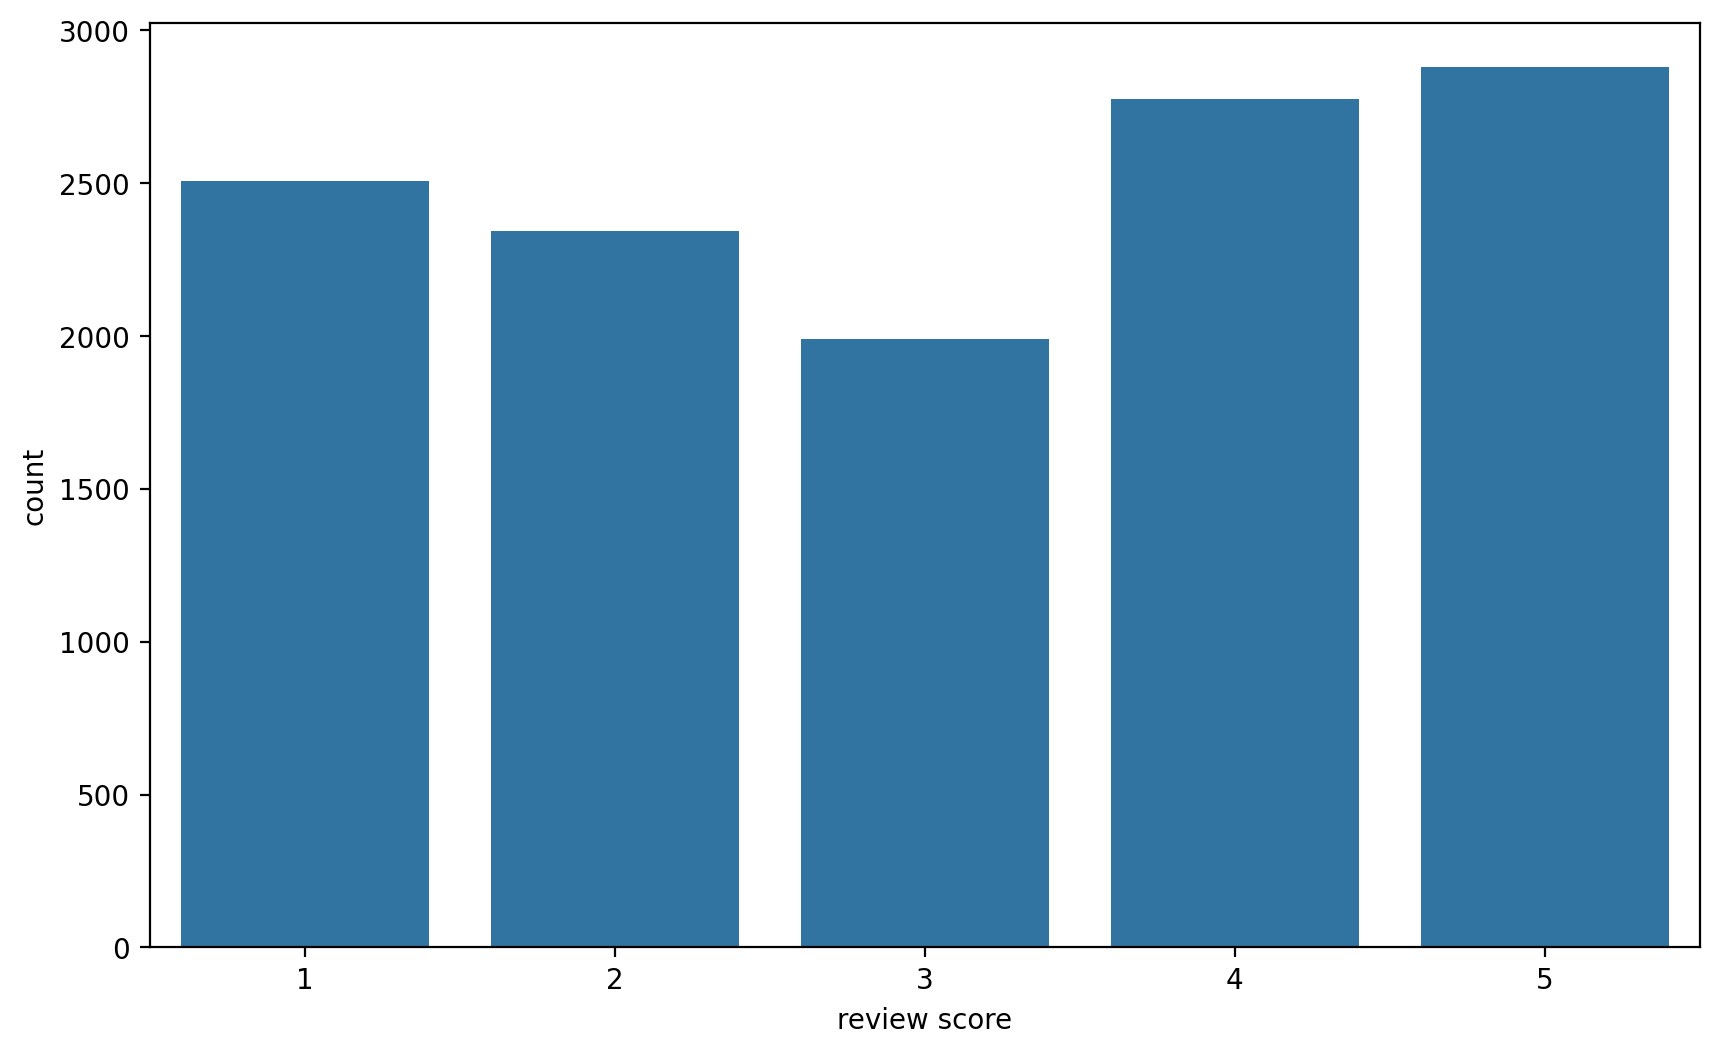

In [ ]:
# Смотрим на распределение классов
sns.countplot(df, x="score")
plt.xlabel('review score')

In [ ]:
# Функция кодировки эмоциональной окраски
def to_sentiment(rating):

    rating = int(rating)

    if rating <= 2:
        return 0
    elif rating <= 4:
        return 1
    else:
        return 2

df['sentiment'] = df.score.apply(to_sentiment)

[Text(0, 0, 'negative'), Text(1, 0, 'neutral'), Text(2, 0, 'positive')]

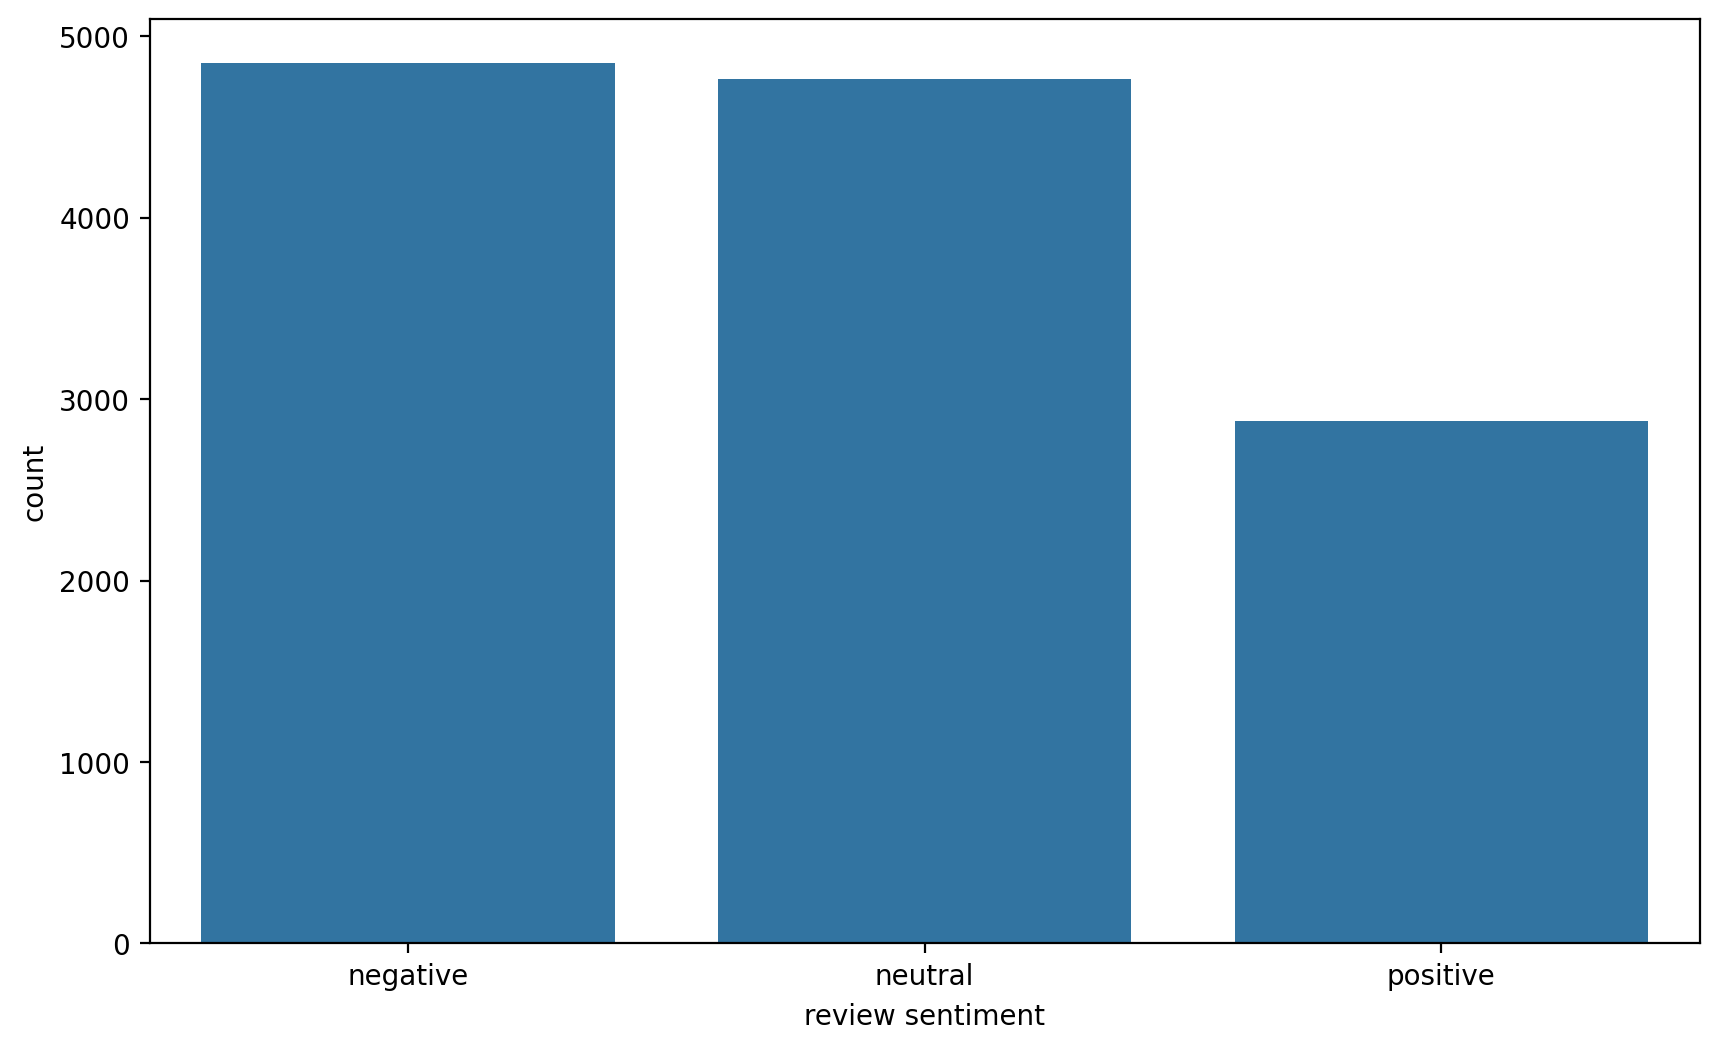

In [ ]:
# Отрисовываем распределение целевой переменной
class_names = ['negative', 'neutral', 'positive']
ax = sns.countplot(df, x="sentiment")
plt.xlabel('review sentiment')
ax.set_xticklabels(class_names)

<div class="alert alert-info">
    
Видим, что у нас 3 класса: негативная тональность, позитивная и нейтральная.

In [ ]:
# Загружаем токенизатор модели
MODEL_NAME = 'bert-base-cased'

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
# Используемые токенизатором BERT токены
print(tokenizer.sep_token, tokenizer.sep_token_id)
print(tokenizer.cls_token, tokenizer.cls_token_id)
print(tokenizer.pad_token, tokenizer.pad_token_id)
print(tokenizer.unk_token, tokenizer.unk_token_id)

[SEP] 102
[CLS] 101
[PAD] 0
[UNK] 100


In [ ]:
# Считаем длину каждого отзыва
token_lens = []

for txt in df.content:
    tokens = tokenizer.encode(txt, max_length=512)
    token_lens.append(len(tokens))

In [ ]:
tokens

[101, 27972, 4064, 1363, 102]

Text(0.5, 0, 'Token count')

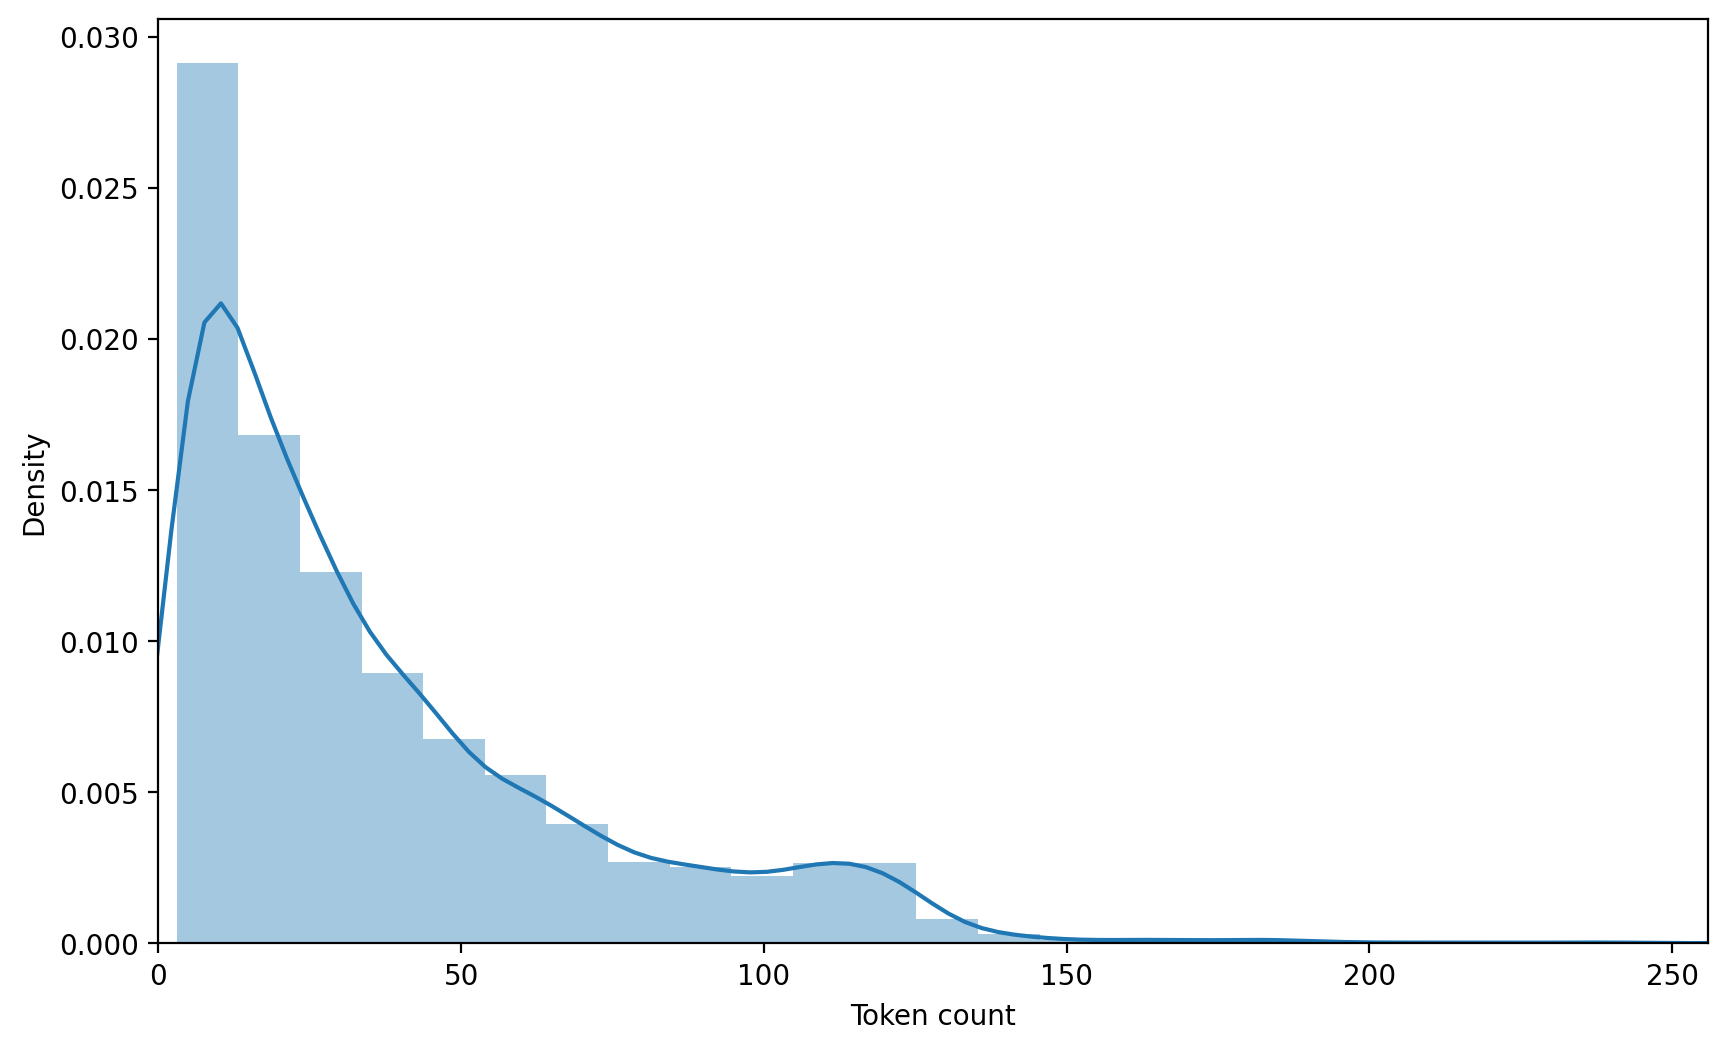

In [ ]:
# Отрисуем длины отзывов
sns.distplot(token_lens)
plt.xlim([0, 256])
plt.xlabel('Token count')

<div class="alert alert-info">

Видим, что в целом все отзывы укладываются в примерно 150 токенов. Значит, можно выставить максимальную длину.

In [ ]:
# Установим максимальную длину
MAX_LEN = 160

In [ ]:
class GPReviewDataset(Dataset):
    # Определяем атрибуты
    def __init__(self, reviews, targets, tokenizer, max_len):
        self.reviews = reviews
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    # Метод подсчета длины
    def __len__(self):
        return len(self.reviews)

    # Метод возврата индекса
    def __getitem__(self, item):
        review = str(self.reviews[item])
        target = self.targets[item]

        # Кодирование
        encoding = self.tokenizer(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            # pad_to_max_length=True,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }

In [ ]:
# Разбиваем на обучающую и валидационную выборки
df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=RANDOM_SEED)

print(df_train.shape, df_val.shape, df_test.shape)

(9996, 13) (1249, 13) (1250, 13)


In [ ]:
# Функция создания загрузчика данных
def create_data_loader(df, tokenizer, max_len, batch_size):
    ds = GPReviewDataset(
        reviews=df.content.to_numpy(),
        targets=df.sentiment.to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        num_workers=0
    )

In [ ]:
BATCH_SIZE = 64
train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

In [ ]:
# Посмотрим, как выглядят данные перед загрузкой в модель
data = next(iter(train_data_loader))
print(data.keys())

print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])
torch.Size([64, 160])
torch.Size([64, 160])
torch.Size([64])


In [ ]:
# Загружаем модель
bert_model = BertModel.from_pretrained(MODEL_NAME)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
bert_model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(28996, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [ ]:
class SentimentClassifier(nn.Module):

    # Создаем атрибуты
    def __init__(self, n_classes):
        super(SentimentClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        self.drop = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    # Прямой проход
    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(
          input_ids=input_ids,
          attention_mask=attention_mask
        )
        pooled_output = bert_output.pooler_output
        # Добавим слой dropout
        output = self.drop(pooled_output)
        return self.classifier(output)

In [ ]:
model = SentimentClassifier(len(class_names))
model = model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# Проверяем размерность скрытого представления
print(bert_model.config.hidden_size)

768


In [ ]:
EPOCHS = 3

# Оптимизатор Adam
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_data_loader) * EPOCHS

# Планировщик скорости обучения
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# Устанавливаем функцию потерь
loss_fn = nn.CrossEntropyLoss().to(device)

<div class="alert alert-info">

Почему AdamW? Эмпирически установлено, что для трансформеров он подходит больше, чем просто Adam. Ключевым отличием является способ добавления регуляризации.

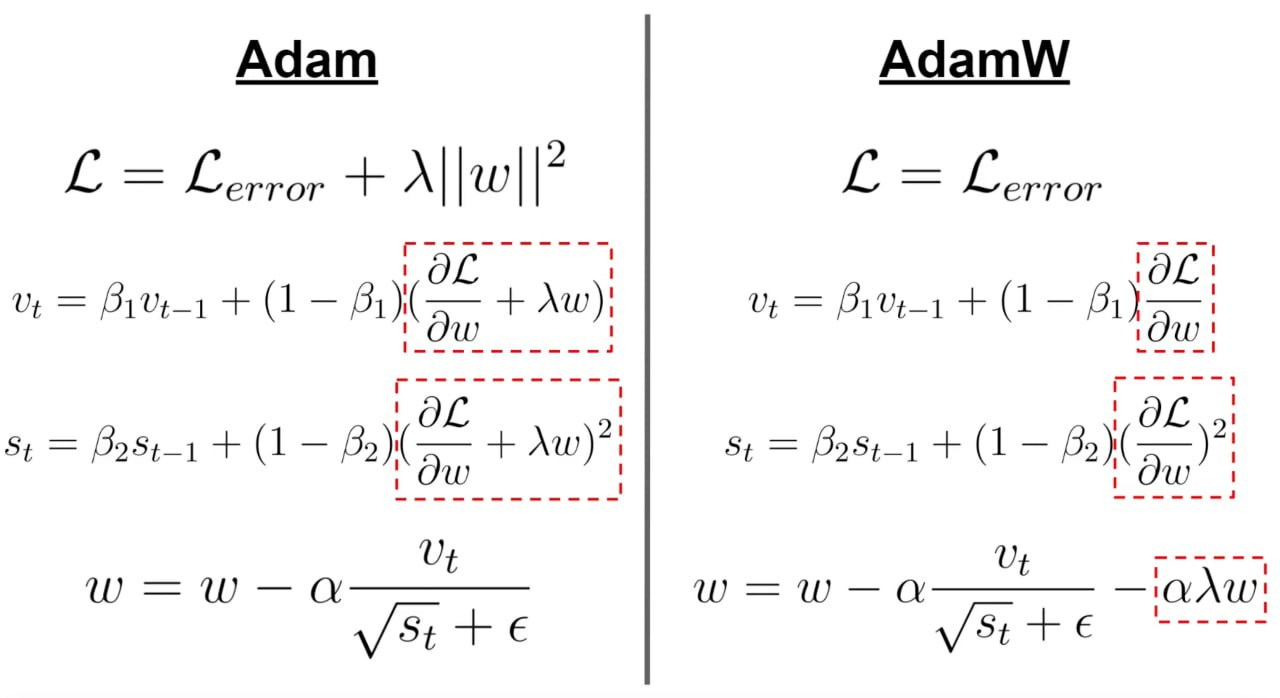

In [ ]:
# Функция обучения модели
def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples, epoch):
    model = model.train()
    losses = []
    correct_predictions = 0

    for d in tqdm(data_loader):
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["targets"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, targets)
        # Записываем результаты в tensoboard
        writer.add_scalar("Loss/train", loss, epoch)
        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())

        # Обратный проход
        loss.backward()

        # Обрезание градиента
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return correct_predictions.double() / n_examples, np.mean(losses)

In [ ]:
# Функция инференса модели
def eval_model(model, data_loader, loss_fn, device, n_examples, epoch):
    model = model.eval()

    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for d in tqdm(data_loader):
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)

            # Получаем ответ модели
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)
            writer.add_scalar("Loss/valid", loss, epoch)
            correct_predictions += torch.sum(preds == targets)
            losses.append(loss.item())

    return correct_predictions.double() / n_examples, np.mean(losses)

In [ ]:
%%time

history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("-" * 10)

    # Считаем функцию потерь и метрику на обучении
    train_acc, train_loss = train_epoch(
        model,
        train_data_loader,
        loss_fn,
        optimizer,
        device,
        scheduler,
        len(df_train),
        epoch
    )

    print(f"Train loss {train_loss} accuracy {train_acc}")

    # Считаем функцию потерь и метрику на валидации
    val_acc, val_loss = eval_model(
        model,
        val_data_loader,
        loss_fn,
        device,
        len(df_val),
        epoch
    )

    print(f"Val loss {val_loss} accuracy {val_acc}")
    print()

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)

    # Если модель на текущем шагу лучше, то сохраняем
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_model_state.bin')
        best_accuracy = val_acc

# Закрываем запись в tensorboard
writer.flush()
writer.close()

Epoch 1/3
----------


100%|██████████| 157/157 [03:51<00:00,  1.48s/it]


Train loss 1.1427713837593225 accuracy 0.38115246098439376


100%|██████████| 20/20 [00:11<00:00,  1.78it/s]


Val loss 1.1114671379327774 accuracy 0.38430744595676536

Epoch 2/3
----------


100%|██████████| 157/157 [03:54<00:00,  1.49s/it]


Train loss 1.1428591453345718 accuracy 0.3786514605842337


100%|██████████| 20/20 [00:10<00:00,  1.90it/s]


Val loss 1.1114671379327774 accuracy 0.38430744595676536

Epoch 3/3
----------


 52%|█████▏    | 82/157 [02:02<01:52,  1.50s/it]

In [ ]:
# Смотрим на результат обучения
# !tensorboard --logdir=runs

In [ ]:
# Отправляем на cpu
history['train_acc'] = [x.cpu() for x in history['train_acc']]
history['val_acc'] = [x.cpu() for x in history['val_acc']]

(0.0, 1.0)

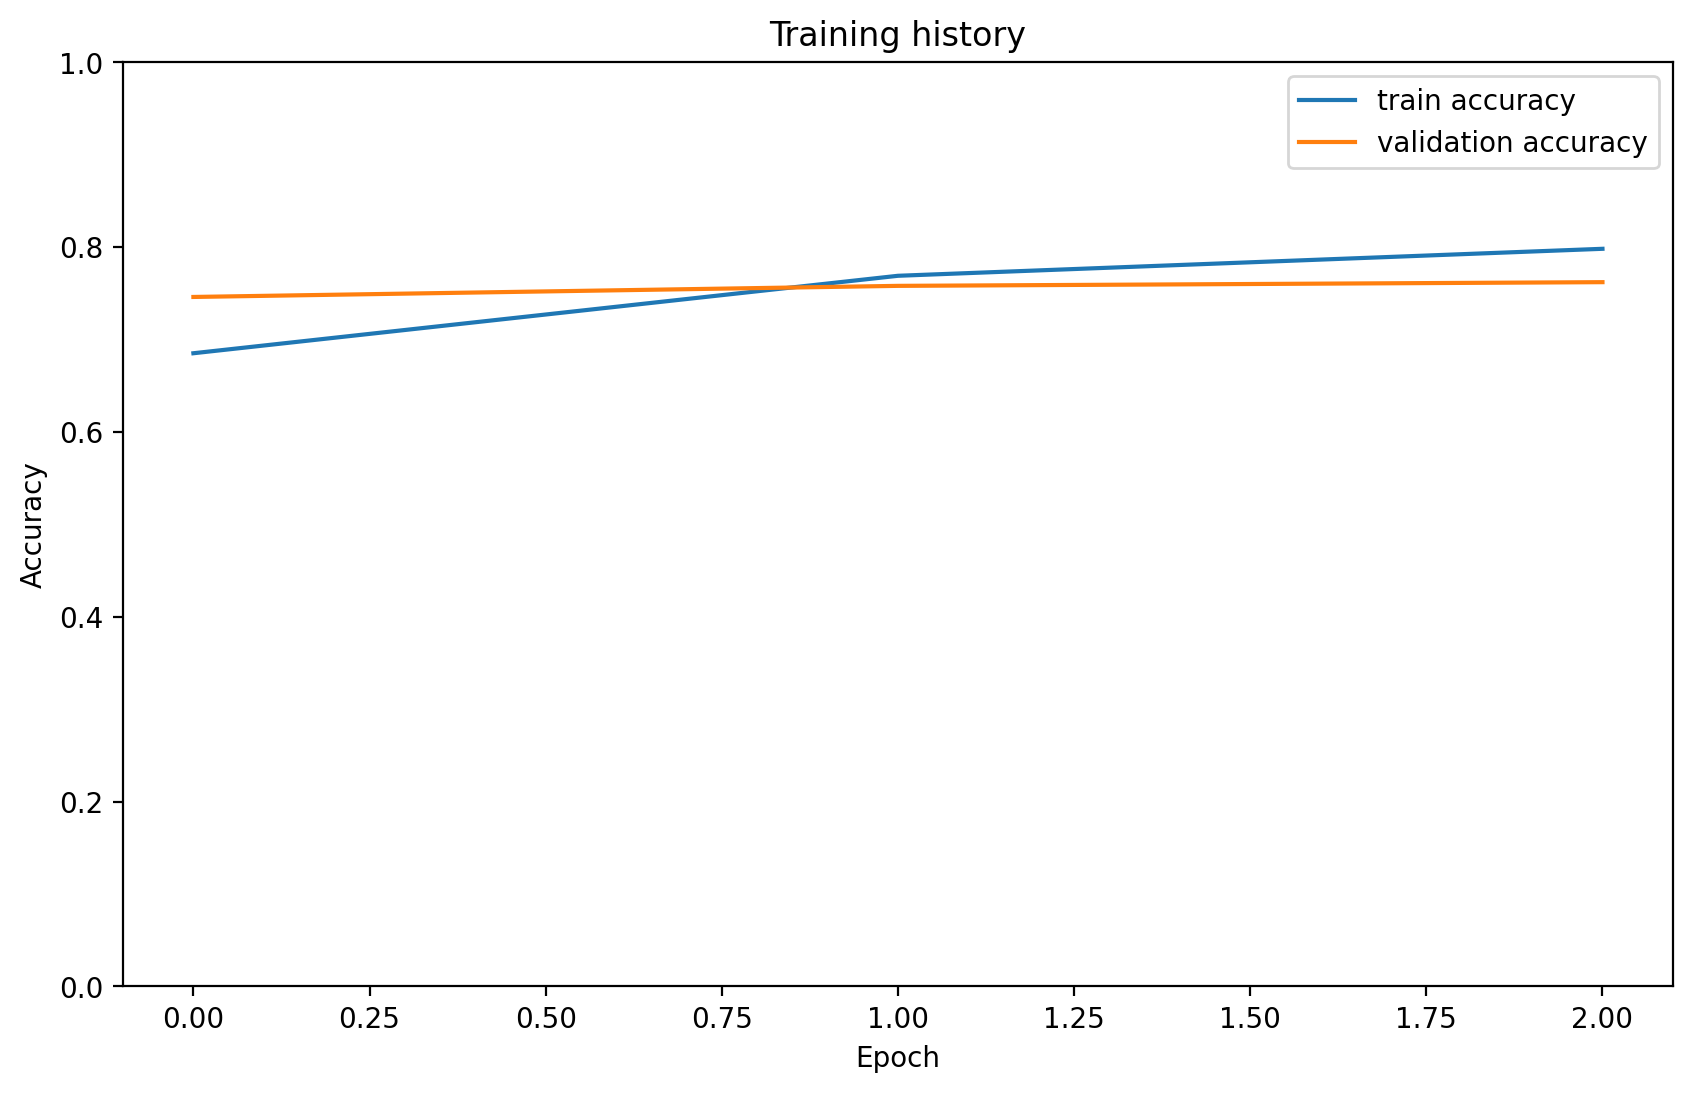

In [ ]:
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

# Отрисуем результаты обучения
plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1])

In [ ]:
test_acc, _ = eval_model(
  model,
  test_data_loader,
  loss_fn,
  device,
  len(df_test),
  epoch
)

test_acc.item()

100%|██████████| 10/10 [00:11<00:00,  1.12s/it]


0.748

<div class="alert alert-info">

Обучение прошло успешно, мы получили хорошие значения метрик.

In [ ]:
# Функция получения предсказания
def get_predictions(model, data_loader):
    model = model.eval()

    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:
            texts = d["review_text"]
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            _, preds = torch.max(outputs, dim=1)

            review_texts.extend(texts)
            predictions.extend(preds)
            prediction_probs.extend(outputs)
            real_values.extend(targets)

    predictions = torch.stack(predictions).cpu()
    prediction_probs = torch.stack(prediction_probs).cpu()
    real_values = torch.stack(real_values).cpu()

    return review_texts, predictions, prediction_probs, real_values

In [ ]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
    model,
    test_data_loader
)

In [ ]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
    model,
    test_data_loader
)

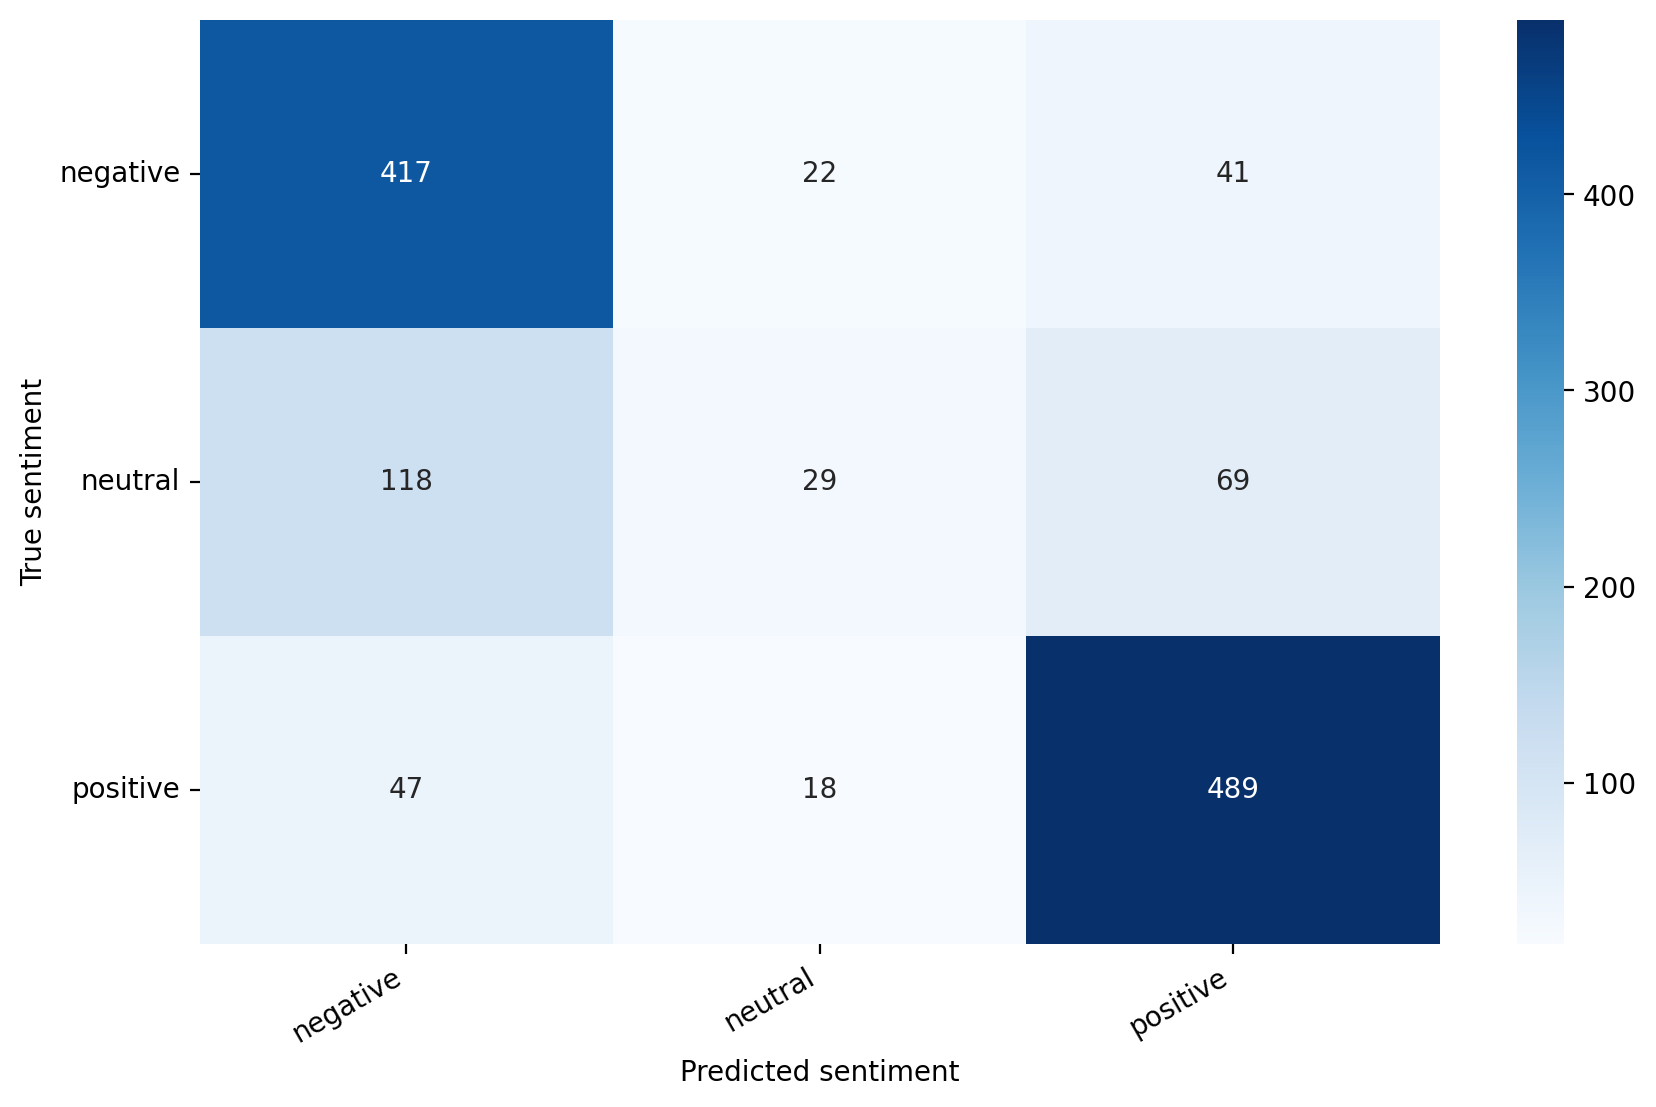

In [ ]:
# Функция отрисовки матрицы ошибок
def show_confusion_matrix(confusion_matrix):
    hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
    hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
    plt.ylabel('True sentiment')
    plt.xlabel('Predicted sentiment');

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
show_confusion_matrix(df_cm)

<div class="alert alert-info">

Ну что ж, результат очень даже приличный. Поздравляем с успешным fine-tune!

In [ ]:
# Случайный комментарий
review_text = "I love completing my todos! Best app ever!!!"

In [ ]:
encoded_review = tokenizer.encode_plus(
    review_text,
    max_length=MAX_LEN,
    add_special_tokens=True,
    return_token_type_ids=False,
    pad_to_max_length=True,
    return_attention_mask=True,
    return_tensors='pt',
)

Keyword arguments {'pad_to_max_length': True} not recognized.


In [ ]:
# Результат
input_ids = encoded_review['input_ids'].to(device)
attention_mask = encoded_review['attention_mask'].to(device)

output = model(input_ids, attention_mask)
_, prediction = torch.max(output, dim=1)

print(f'Review text: {review_text}')
print(f'Sentiment: {class_names[prediction]}')

Review text: I love completing my todos! Best app ever!!!
Sentiment: positive


# <center id="a2"> Fine-tune только классифицирующей головы

Давайте повторим предыдущий эксперимент. С той лишь разницей, что мы заморозим все веса BERT, кроме последнего классифицирующего слоя. Скорость обучения значительно вырастет, а вот что будет с качеством?

In [ ]:
model = SentimentClassifier(len(class_names))
model = model.to(device)

In [ ]:
for param in model.bert.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):

    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("-" * 10)

    # Считаем функцию потерь и метрику на обучении
    train_acc, train_loss = train_epoch(
        model,
        train_data_loader,
        loss_fn,
        optimizer,
        device,
        scheduler,
        len(df_train),
        epoch
    )

    print(f"Train loss {train_loss} accuracy {train_acc}")

    # Считаем функцию потерь и метрику на валидации
    val_acc, val_loss = eval_model(
        model,
        val_data_loader,
        loss_fn,
        device,
        len(df_val),
        epoch
    )

    print(f"Val loss {val_loss} accuracy {val_acc}")
    print()

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)

    # Если модель на текущем шагу лучше, то сохраняем
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_model_state.bin')
        best_accuracy = val_acc

writer.flush()
writer.close()

Epoch 1/3
----------


100%|██████████| 79/79 [01:31<00:00,  1.15s/it]


Train loss 1.1280783565738532 accuracy 0.4011604641856743


100%|██████████| 10/10 [00:11<00:00,  1.13s/it]


Val loss 1.103714942932129 accuracy 0.4531625300240192

Epoch 2/3
----------


...

Val loss 1.103714942932129 accuracy 0.4531625300240192

Epoch 3/3
----------


100%|██████████| 79/79 [01:31<00:00,  1.16s/it]


Train loss 1.1276271614847304 accuracy 0.3955582232893158


100%|██████████| 10/10 [00:11<00:00,  1.13s/it]

Val loss 1.103714942932129 accuracy 0.4531625300240192



In [ ]:
# Отправляем на cpu
history['train_acc'] = [x.cpu() for x in history['train_acc']]
history['val_acc'] = [x.cpu() for x in history['val_acc']]

(0.0, 1.0)

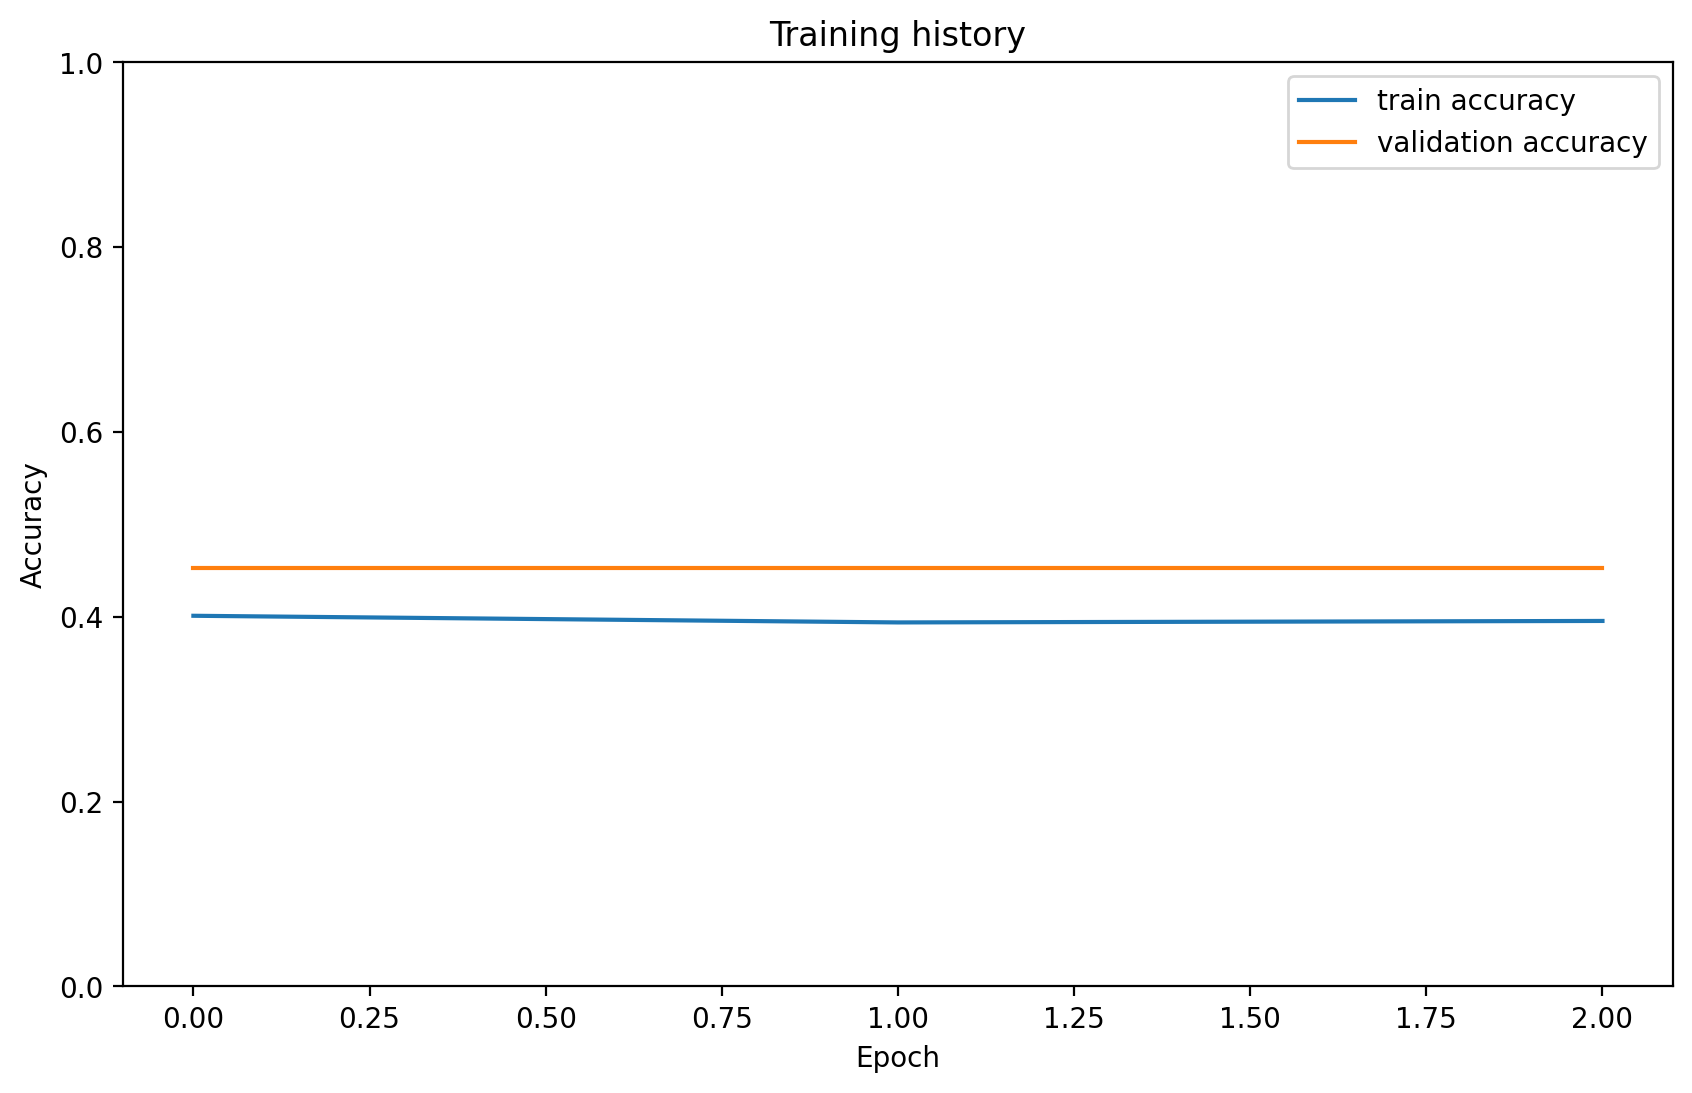

In [ ]:
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

# Отрисуем результаты обучения
plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1])

In [ ]:
test_acc, _ = eval_model(
  model,
  test_data_loader,
  loss_fn,
  device,
  len(df_test),
  epoch
)

test_acc.item()

100%|██████████| 10/10 [00:11<00:00,  1.13s/it]


0.44480000000000003

In [ ]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
    model,
    test_data_loader
)

In [ ]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
    model,
    test_data_loader
)

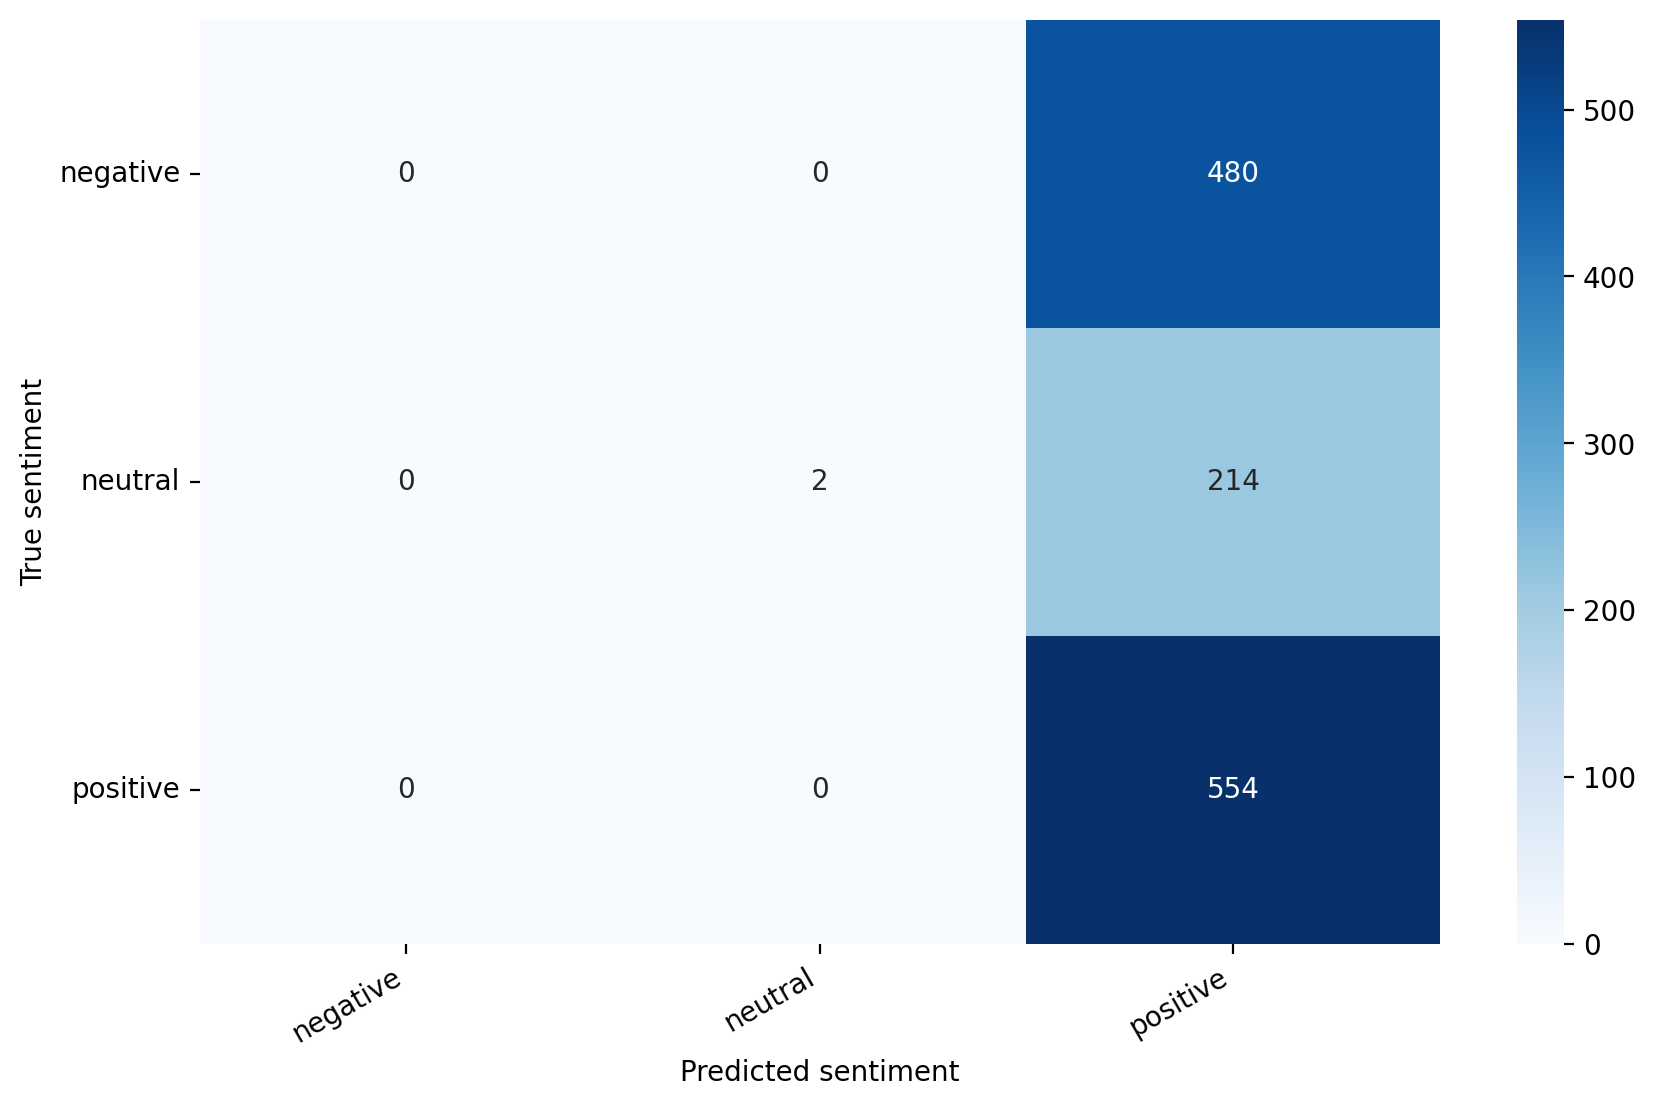

In [ ]:
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
show_confusion_matrix(df_cm)

<div class="alert alert-warning">

Можно заметить, что качество стало значительно хуже. Как вы думаете, с чем это связано?

In [ ]:
! pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00


In [ ]:
# Импортируем библиотеки
import torch

from torch.optim import AdamW
from transformers import AutoTokenizer, BertForTokenClassification, TrainingArguments, Trainer
from transformers import get_linear_schedule_with_warmup
from datasets import load_dataset
import numpy as np

# Проверяем доступность GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")


Используемое устройство: cuda


In [ ]:
# Загружаем датасет CONLL-2003 через Hugging Face Datasets
dataset = load_dataset("rjac/kaggle-entity-annotated-corpus-ner-dataset")

# # Посмотрим на один пример из тренировочной выборки
example = dataset["train"][0]
print("Пример из датасета CONLL-2003 (токены и метки):")
print(example)


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

(…)-00000-of-00004-e7c482bd9e74046f.parquet:   0%|          | 0.00/857k [00:00<?, ?B/s]

(…)-00001-of-00004-8e5af59a8884c020.parquet:   0%|          | 0.00/860k [00:00<?, ?B/s]

(…)-00002-of-00004-8838aa9871a9e9b2.parquet:   0%|          | 0.00/857k [00:00<?, ?B/s]

(…)-00003-of-00004-d4161cf902a01090.parquet:   0%|          | 0.00/823k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/47959 [00:00<?, ? examples/s]

Пример из датасета CONLL-2003 (токены и метки):
{'sentence_id': ' 1', 'tokens': ['Thousands', 'of', 'demonstrators', 'have', 'marched', 'through', 'London', 'to', 'protest', 'the', 'war', 'in', 'Iraq', 'and', 'demand', 'the', 'withdrawal', 'of', 'British', 'troops', 'from', 'that', 'country', '.'], 'ner_tags': [0, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 7, 0, 0, 0, 0, 0]}


# Named Entity Recognition

In [ ]:
! pip install datasets transformers[torch] seqeval corus evaluate razdel -q
! pip install accelerate -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 8.0 MB/s eta 0:00:00


В этой части блокнота мы дообучаем модель на задаче классификации отдельных слов, а именно, распознавание именованных сущностей (aka named entity recognition, aka NER). Мы возьмём датасет медицинских сущностей, но в целом пайплайн подходит для любой задачи на выделение сущностей в тексте.

Для скорости мы возьмём маленький BERT для русского языка [rubert-tiny](https://huggingface.co/cointegrated/rubert-tiny2); если взять другую, более крупную BERT-подобную модель, качество NER может быть выше, но и время обучения и работы будет дольше


In [ ]:
model_checkpoint = "cointegrated/rubert-tiny2"
batch_size = 16

## Загрузка данных

Для обучения мы возьмём [Russian Drug Reaction Corpus](https://github.com/cimm-kzn/RuDReC): размеченный корпус русскоязычных отзывов на лекарства.

Загрузим мы его библиотекой corus, потому что это удобно

In [ ]:
import torch
import logging
import numpy as np
import pandas as pd

from razdel import tokenize
from corus import load_rudrec
from evaluate import load as load_metric
from collections import Counter, defaultdict
from datasets import load_dataset, Dataset, DatasetDict  # , load_metric

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from transformers.trainer import logger as noisy_logger
from transformers import (
    Trainer,
    pipeline,
    AutoTokenizer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    AutoModelForTokenClassification
)

noisy_logger.setLevel(logging.WARNING)

In [ ]:
!wget https://github.com/cimm-kzn/RuDReC/raw/master/data/rudrec_annotated.json

--2025-09-09 22:53:29--  https://github.com/cimm-kzn/RuDReC/raw/master/data/rudrec_annotated.json
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/cimm-kzn/RuDReC/master/data/rudrec_annotated.json [following]
--2025-09-09 22:53:30--  https://raw.githubusercontent.com/cimm-kzn/RuDReC/master/data/rudrec_annotated.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1773014 (1.7M) [text/plain]
Saving to: ‘rudrec_annotated.json’

rudrec_annotated.js 100%[===================>]   1.69M  --.-KB/s    in 0.009s  

2025-09-09 22:53:31 (191 MB/s) - ‘rudrec_annotated.json’ saved [1773014/1773014]



In [ ]:
drugs = list(load_rudrec('rudrec_annotated.json'))
print(len(drugs))

4809


Пример документа:

In [ ]:
drugs[0]

RuDReCRecord(
    file_name='172744.tsv',
    text='нам прописали, так мой ребенок сыпью покрылся, глаза опухли, сверху и снизу на веках высыпала сыпь, ( 8 месяцев сыну)А от виферона такого не было... У кого ещё такие побочки, отзовитесь!1 Чем спасались?\n',
    sentence_id=0,
    entities=[RuDReCEntity(
         entity_id='*[0]_se',
         entity_text='виферона',
         entity_type='Drugform',
         start=122,
         end=130,
         concept_id='C0021735',
         concept_name=nan
     ),
     RuDReCEntity(
         entity_id='*[1]',
         entity_text='сыпью покрылся',
         entity_type='ADR',
         start=31,
         end=45,
         concept_id='C0015230',
         concept_name=nan
     ),
     RuDReCEntity(
         entity_id='*[2]',
         entity_text='глаза опухли',
         entity_type='ADR',
         start=47,
         end=59,
         concept_id='C4760994',
         concept_name=nan
     ),
     RuDReCEntity(
         entity_id='*[3]',
         entity_text

Посмотрим, какие сущности есть: лекарства, форма лекарств, класс лекарств, показания к применению, побочки, и прочие болезни/симптомы.

https://arxiv.org/abs/2004.03659

* **DRUGNAME** Mentions of the brand name of a drug or product
ingredients/active compounds.
* **DRUGCLASS** Mentions of drug classes such as anti-inflammatory or
cardiovascular.
* **DRUGFORM** Mentions of routes of administration such as tablet
or liquid that describe the physical form in which
medication will be delivered into patient’s organism.
* **DI** Any indication/symptom that specifies the reason for
taking/prescribing the drug.
* **ADR** Mentions of untoward medical events that occur as a
consequence of drug intake and are not associated with
treated symptoms.
* **FINDING** Any DI or ADR that was not directly experienced by the
reporting patient or his/her family members, or related to
medical history/drug label, or any disease entities if the
annotator is not clear about type

In [ ]:
type2text = defaultdict(Counter)
ents = Counter()

for item in drugs:
    for e in item.entities:
        ents[e.entity_type] += 1
        type2text[e.entity_type][e.entity_text] += 1

for k, v in ents.most_common():
    print(k, v)
    print(type2text[k].most_common(3))

DI 1401
[('простуды', 64), ('ОРВИ', 47), ('профилактики', 42)]
Drugname 1043
[('Виферон', 33), ('Анаферон', 25), ('Циклоферон', 24)]
Drugform 836
[('таблетки', 154), ('таблеток', 79), ('свечи', 63)]
ADR 720
[('аллергия', 16), ('слабость', 13), ('диарея', 12)]
Drugclass 330
[('противовирусный', 21), ('противовирусное', 18), ('противовирусных', 13)]
Finding 236
[('аллергии', 12), ('температуры', 6), ('сонливости', 5)]


In [ ]:
drugs[0].text

'нам прописали, так мой ребенок сыпью покрылся, глаза опухли, сверху и снизу на веках высыпала сыпь, ( 8 месяцев сыну)А от виферона такого не было... У кого ещё такие побочки, отзовитесь!1 Чем спасались?\n'

Напишем функцию, перекладывающую разметку сущностей на уровень слов. Будем использовать [IOB](https://en.wikipedia.org/wiki/Inside–outside–beginning_(tagging))-нотацию, чтобы разделять несколько сущностей одного типа, идущих подряд.

In [ ]:
def extract_labels(item):
    raw_toks = list(tokenize(item.text))
    words = [tok.text for tok in raw_toks]
    word_labels = ['O'] * len(raw_toks)
    char2word = [None] * len(item.text)

    for i, word in enumerate(raw_toks):
        char2word[word.start:word.stop] = [i] * len(word.text)

    for e in item.entities:
        e_words = sorted({idx for idx in char2word[e.start:e.end] if idx is not None})
        word_labels[e_words[0]] = 'B-' + e.entity_type

        for idx in e_words[1:]:
            word_labels[idx] = 'I-' + e.entity_type

    return {'tokens': words, 'tags': word_labels}

In [ ]:
print(extract_labels(drugs[0]))

{'tokens': ['нам', 'прописали', ',', 'так', 'мой', 'ребенок', 'сыпью', 'покрылся', ',', 'глаза', 'опухли', ',', 'сверху', 'и', 'снизу', 'на', 'веках', 'высыпала', 'сыпь', ',', '(', '8', 'месяцев', 'сыну', ')', 'А', 'от', 'виферона', 'такого', 'не', 'было', '...', 'У', 'кого', 'ещё', 'такие', 'побочки', ',', 'отзовитесь', '!', '1', 'Чем', 'спасались', '?'], 'tags': ['O', 'O', 'O', 'O', 'O', 'O', 'B-ADR', 'I-ADR', 'O', 'B-ADR', 'I-ADR', 'O', 'O', 'O', 'O', 'B-ADR', 'I-ADR', 'I-ADR', 'I-ADR', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-Drugform', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']}


In [ ]:
ner_data = [extract_labels(item) for item in drugs]

ner_train, ner_test = train_test_split(ner_data, test_size=0.2, random_state=1)

Пример данных

In [ ]:
pd.options.display.max_colwidth = 300

pd.DataFrame(ner_train).sample(3)

,tokens,tags
3692,"[Мочить, плечо, запретили, .]","[O, O, O, O]"
184,"[Горло, как, было, красное, так, и, осталось, .]","[B-DI, I-DI, I-DI, I-DI, O, O, O, O]"
1621,"[Одной, упаковкой, не, обойтись, .]","[O, O, O, O, O]"


Соберём все виды меток в список.

In [ ]:
label_list = sorted({label for item in ner_train for label in item['tags']})
if 'O' in label_list:
    label_list.remove('O')
    label_list = ['O'] + label_list
label_list

['O',
 'B-ADR',
 'B-DI',
 'B-Drugclass',
 'B-Drugform',
 'B-Drugname',
 'B-Finding',
 'I-ADR',
 'I-DI',
 'I-Drugclass',
 'I-Drugform',
 'I-Drugname',
 'I-Finding']

Сложим наши данные в объект [`DatasetDict`](https://huggingface.co/docs/datasets/package_reference/main_classes.html#datasetdict), нативный для huggingface.

In [ ]:
ner_data = DatasetDict({
    'train': Dataset.from_pandas(pd.DataFrame(ner_train)),
    'test': Dataset.from_pandas(pd.DataFrame(ner_test))
})
ner_data

DatasetDict({
    train: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 3847
    })
    test: Dataset({
        features: ['tokens', 'tags'],
        num_rows: 962
    })
})

## Подготовка данных

Прежде чем подавать тексты в модель, их необходимо предобработать. Этим занимается токенизатор 🤗 Transformers (`Tokenizer`), который:  
- токенизирует входные данные (включая преобразование токенов в соответствующие идентификаторы из предобученного словаря)  
- форматирует данные согласно ожиданиям модели  
- генерирует дополнительные входные параметры, требуемые моделью.  

Для этого мы инициализируем токенизатор методом `AutoTokenizer.from_pretrained`, гарантирующим:  
- соответствие токенизатора архитектуре выбранной модели,  
- загрузку словаря, использованного при предобучении данного чекпоинта.  

Словарь будет закеширован, поэтому повторная загрузка при следующем запуске ячейки не потребуется.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
tokenizer("Hello, this is one sentence!")

{'input_ids': [2, 9944, 16, 881, 550, 835, 15503, 5, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

В зависимости от выбранной модели, вы увидите разные ключи в словаре, возвращаемом ячейкой выше. Они не столь важны для текущей задачи (просто знайте, что они требуются для инициализируемой позже модели). Подробнее о них можно узнать в [этом руководстве](https://huggingface.co/transformers/preprocessing.html).  

Если ваши входные данные уже разбиты на слова (как в данном случае), передайте список слов в токенизатор с аргументом `is_split_into_words=True`.

In [ ]:
tokenizer(["Hello", ",", "this", "is", "one", "sentence", "split", "into", "words", "."], is_split_into_words=True)

{'input_ids': [2, 9944, 16, 881, 550, 835, 15503, 7440, 996, 6301, 18, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
example = ner_train[5]
print(example["tokens"])

['Мы', 'поменяли', 'место', 'жительства', 'и', 'перевели', 'дочь', 'в', 'школу', ',', 'которая', 'находится', 'ближе', 'к', 'дому', '.']


In [ ]:
tokenized_input = tokenizer(example["tokens"], is_split_into_words=True)
tokens = tokenizer.convert_ids_to_tokens(tokenized_input["input_ids"])
print(tokens)

['[CLS]', 'Мы', 'поменяли', 'место', 'жительства', 'и', 'перевели', 'дочь', 'в', 'школу', ',', 'которая', 'находится', 'ближе', 'к', 'дому', '.', '[SEP]']


Чтобы перейти с уровня слов на уровень subword tokens, нужно ещё раз предобработать тексты.

In [ ]:
len(example["tags"]), len(tokenized_input["input_ids"])

(16, 18)

In [ ]:
print(tokenized_input.word_ids())

[None, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, None]


Как видим, он возвращает список с тем же количеством элементов, что и наши обработанные идентификаторы ввода (`input_ids`), сопоставляя:  
- специальные токены со значением `None`  
- остальные токены с соответствующими им словами.  

Таким образом мы можем сопоставить метки с обработанными идентификаторами ввода.

In [ ]:
word_ids = tokenized_input.word_ids()
aligned_labels = [-100 if i is None else example["tags"][i] for i in word_ids]
print(len(aligned_labels), len(tokenized_input["input_ids"]))

18 18


Здесь мы устанавливаем метки для:  
- всех специальных токенов: **-100** (индекс, игнорируемый PyTorch)  
- остальных токенов: **метка исходного слова**, к которому они относятся.  

Альтернативная стратегия: присваивать метку только **первому токену слова**, а остальным субтокенам того же слова давать метку **-100**.  
Обе стратегии доступны через переключение флага `label_all_tokens`.

Теперь мы готовы написать функцию предобработки образцов. Передаём их в `tokenizer` с аргументами:  
- `truncation=True` (для усечения текстов, превышающих максимальный размер модели)  
- `is_split_into_words=True` (как упомянуто ранее).  

Затем выравниваем метки с идентификаторами токенов, используя выбранную стратегию:

In [ ]:
def tokenize_and_align_labels(examples, label_all_tokens=False):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)

    labels = []
    for i, label in enumerate(examples['tags']):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            # Special tokens have a word id that is None. We set the label to -100 so they are automatically
            # ignored in the loss function.
            if word_idx is None:
                label_ids.append(-100)
            # We set the label for the first token of each word.
            elif word_idx != previous_word_idx:
                label_ids.append(label[word_idx])
            # For the other tokens in a word, we set the label to either the current label or -100, depending on
            # the label_all_tokens flag.
            else:
                label_ids.append(label[word_idx] if label_all_tokens else -100)
            previous_word_idx = word_idx

        label_ids = [label_list.index(idx) if isinstance(idx, str) else idx for idx in label_ids]

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [ ]:
tokenize_and_align_labels(ner_data['train'][22:23])

{'input_ids': [[2, 1041, 37038, 33265, 19106, 40305, 22018, 548, 22276, 320, 21538, 16, 47886, 548, 59614, 11137, 626, 56606, 700, 18, 3]], 'token_type_ids': [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], 'labels': [[-100, 0, 0, 0, 0, 1, -100, 7, 7, 7, 7, 0, 0, 0, 0, -100, -100, 0, -100, 0, -100]]}

In [ ]:
tokenized_datasets = ner_data.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/3847 [00:00<?, ? examples/s]

Map:   0%|          | 0/962 [00:00<?, ? examples/s]

Что ещё удобнее: результаты автоматически кешируются библиотекой 🤗 Datasets, чтобы избежать повторного выполнения этого шага при следующем запуске блокнота. Библиотека 🤗 Datasets обычно достаточно умна, чтобы определить, когда изменяется переданная в `map` функция (и, следовательно, требуется не использовать закешированные данные). Например, она корректно распознает изменение задачи в первой ячейке и перезапуск блокнота.  

🤗 Datasets предупредит при использовании кешированных файлов. Чтобы игнорировать кеш и принудительно повторно выполнить предобработку, передайте `load_from_cache_file=False` в вызове `map`.  

Обратите внимание: мы указали `batched=True` для **пакетного** кодирования текстов. Это позволяет максимально использовать преимущества **быстрого токенизатора**, загруженного ранее, который применяет многопоточность для параллельной обработки текстов в пакете.

## Дообучение модели

Теперь, когда данные готовы, мы можем загрузить предобученную модель и дообучить её. Поскольку наша задача относится к токенной классификации, используем класс `AutoModelForTokenClassification`. Как и в случае с токенизатором, метод `from_pretrained` загрузит и закеширует модель. Единственный параметр, который необходимо указать — количество меток для нашей задачи (его можно получить из фичей, как показано ранее):

In [ ]:
label_list

['O',
 'B-ADR',
 'B-DI',
 'B-Drugclass',
 'B-Drugform',
 'B-Drugname',
 'B-Finding',
 'I-ADR',
 'I-DI',
 'I-Drugclass',
 'I-Drugform',
 'I-Drugname',
 'I-Finding']

In [ ]:
model = AutoModelForTokenClassification.from_pretrained(model_checkpoint, num_labels=len(label_list))
model.config.id2label = dict(enumerate(label_list))
model.config.label2id = {v: k for k, v in model.config.id2label.items()}

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Предупреждение сообщает, что мы:  
- **отбрасываем** часть весов (слои `vocab_transform` и `vocab_layer_norm`)  
- **случайно инициализируем** другие слои (`pre_classifier` и `classifier`).  

Это абсолютно нормально, поскольку мы:  
1. Удаляем голову модели, использовавшуюся для предобучения (masked language modeling)  
2. Заменяем её **новой головой** без предобученных весов.  

Библиотека предупреждает: перед инференсом модель необходимо **дообучить** — чем мы и займёмся.

Чтобы инициализировать `Trainer`, нам потребуется определить ещё три компонента. Наиболее важный — [`TrainingArguments`](https://huggingface.co/transformers/main_classes/trainer.html#transformers.TrainingArguments): класс, содержащий все атрибуты для настройки обучения. Обязательным является только указание имени папки для сохранения контрольных точек модели — остальные аргументы опциональны:

In [ ]:
args = TrainingArguments(
    "ner",
    eval_strategy = "epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=10,
    weight_decay=0.01,
    save_strategy='no',
    report_to='none',
    include_inputs_for_metrics=True,
)

Using `include_inputs_for_metrics` is deprecated and will be removed in version 5 of 🤗 Transformers. Please use `include_for_metrics` list argument instead.


Здесь мы настраиваем:  
- оценку (**evaluation**) в конце каждой эпохи  
- корректировку **learning rate**  
- использование `batch_size`, заданного в начале блокнота  
- количество эпох обучения (**epochs**)  
- снижение весов (**weight decay**).  

Затем нам понадобится **формирователь батчей** (data collator), который:  
- объединяет обработанные примеры в батчи  
- применяет **дополнение** (padding) для выравнивания по длине самого длинного примера.  

Библиотека Transformers предоставляет специализированный формирователь для этой задачи, дополняющий не только входные данные, но и метки:

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer)

Последний элемент для настройки `Trainer` — вычисление метрик на основе предсказаний. Мы загрузим метрику [`seqeval`](https://github.com/chakki-works/seqeval) (стандартную для оценки на датасете CONLL) через библиотеку Datasets.

In [ ]:
metric = load_metric("seqeval")

In [ ]:
example = ner_train[4]
labels = example['tags']
metric.compute(predictions=[labels], references=[labels])

{'DI': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(1)},
 'Drugform': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(2)},
 'overall_precision': np.float64(1.0),
 'overall_recall': np.float64(1.0),
 'overall_f1': np.float64(1.0),
 'overall_accuracy': 1.0}

Для вычисления метрик потребуется постобработка предсказаний:  
1. Выбрать **предсказанный индекс** (с максимальным логитом) для каждого токена  
2. Преобразовать его в **строковую метку**  
3. Игнорировать элементы с меткой **-100**  

Следующая функция выполняет эту постобработку результатов `Trainer.evaluate` (которые возвращаются как именованный кортеж с предсказаниями и метками) перед применением метрики:

In [ ]:
def compute_metrics(p):
    predictions, labels, inputs = p.predictions, p.label_ids, p.inputs
    predictions = np.argmax(p.predictions, axis=2)

    # send only the first token of each word to the evaluation
    true_predictions = []
    true_labels = []
    for prediction, label, tokens in zip(predictions, labels, inputs):
        true_predictions.append([])
        true_labels.append([])
        for (p, l, t) in zip(prediction, label, tokens):
            if l != -100 and not tokenizer.convert_ids_to_tokens(int(t)).startswith('##'):
                true_predictions[-1].append(label_list[p])
                true_labels[-1].append(label_list[l])

    results = metric.compute(predictions=true_predictions, references=true_labels, zero_division=0)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.evaluate()

{'eval_loss': 2.4042954444885254,
 'eval_model_preparation_time': 0.0008,
 'eval_precision': 0.0071972904318374255,
 'eval_recall': 0.07188160676532769,
 'eval_f1': 0.013084471810659996,
 'eval_accuracy': 0.20972150402600281,
 'eval_runtime': 0.6707,
 'eval_samples_per_second': 1434.219,
 'eval_steps_per_second': 90.943}

В начале обучения заморозим все параметры в модели, кроме последнего слоя, и посмотрим, насколько хорошо она обучится.

In [ ]:
for param in model.bert.parameters():
    param.requires_grad = False

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)
        print(param)

classifier.weight
Parameter containing:
tensor([[ 0.0136, -0.0212,  0.0015,  ..., -0.0077,  0.0166,  0.0369],
        [-0.0442,  0.0343,  0.0095,  ...,  0.0271, -0.0292,  0.0075],
        [ 0.0122, -0.0065,  0.0319,  ...,  0.0013, -0.0092, -0.0120],
        ...,
        [-0.0205, -0.0105,  0.0295,  ..., -0.0041, -0.0083, -0.0112],
        [-0.0362, -0.0381, -0.0175,  ...,  0.0036, -0.0401, -0.0299],
        [ 0.0132,  0.0472, -0.0325,  ...,  0.0254, -0.0118, -0.0187]],
       device='cuda:0', requires_grad=True)
classifier.bias
Parameter containing:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0',
       requires_grad=True)


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Precision,Recall,F1,Accuracy
1,No log,1.830504,0.000800,0.009302,0.010571,0.009896,0.836818
2,No log,1.386738,0.000800,0.000000,0.000000,0.000000,0.898057
3,1.835700,1.068947,0.000800,0.000000,0.000000,0.000000,0.900643
4,1.835700,0.858257,0.000800,0.000000,0.000000,0.000000,0.900864
5,1.062000,0.725041,0.000800,0.000000,0.000000,0.000000,0.900864
6,1.062000,0.643298,0.000800,0.000000,0.000000,0.000000,0.900864
7,0.715500,0.593980,0.000800,0.000000,0.000000,0.000000,0.900864
8,0.715500,0.565116,0.000800,0.000000,0.000000,0.000000,0.900864
9,0.583400,0.550089,0.000800,0.000000,0.000000,0.000000,0.900864
10,0.583400,0.545454,0.000800,0.000000,0.000000,0.000000,0.900864


TrainOutput(global_step=2410, training_loss=0.9627020808176381, metrics={'train_runtime': 24.7948, 'train_samples_per_second': 1551.537, 'train_steps_per_second': 97.198, 'total_flos': 24697669954800.0, 'train_loss': 0.9627020808176381, 'epoch': 10.0})

Модель недообучилась: похоже, что нужно обучить больше слоёв. Разморозим их все (но, воможно, более правильно было бы разморозить лишь несколько верхних), и поучимся ещё эпох 20.

In [ ]:
# разморозка
for param in model.parameters():
    param.requires_grad = True

In [ ]:
args = TrainingArguments(
    "ner",
    eval_strategy = "epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=20,
    weight_decay=0.01,
    save_strategy='no',
    report_to='none',
    include_inputs_for_metrics=True,
)

Using `include_inputs_for_metrics` is deprecated and will be removed in version 5 of 🤗 Transformers. Please use `include_for_metrics` list argument instead.


In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.323147,0.530398,0.267442,0.355587,0.919037
2,No log,0.280852,0.481390,0.410148,0.442922,0.928197
3,0.323100,0.256066,0.486207,0.447146,0.465859,0.931743
4,0.323100,0.240475,0.510360,0.494715,0.502415,0.935141
5,0.233500,0.228564,0.513678,0.535941,0.524573,0.937800
6,0.233500,0.219048,0.539225,0.573996,0.556068,0.941494
7,0.200600,0.210017,0.559548,0.576110,0.567708,0.943488
8,0.200600,0.205738,0.541395,0.615222,0.575952,0.943931
9,0.174300,0.199733,0.563033,0.627907,0.593703,0.945335
10,0.174300,0.196690,0.560748,0.634249,0.595238,0.946221


TrainOutput(global_step=4820, training_loss=0.1777695580636812, metrics={'train_runtime': 103.0799, 'train_samples_per_second': 746.411, 'train_steps_per_second': 46.76, 'total_flos': 49424108009730.0, 'train_loss': 0.1777695580636812, 'epoch': 20.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.18425579369068146,
 'eval_precision': 0.5936626281453867,
 'eval_recall': 0.6733615221987315,
 'eval_f1': 0.6310054482417038,
 'eval_accuracy': 0.9510231218142867,
 'eval_runtime': 0.5376,
 'eval_samples_per_second': 1789.331,
 'eval_steps_per_second': 113.461,
 'epoch': 20.0}

In [ ]:
p = trainer.predict(tokenized_datasets["test"])


predictions, labels, inputs = p.predictions, p.label_ids, tokenized_datasets["test"]['input_ids']
predictions = np.argmax(p.predictions, axis=2)

# send only the first token of each word to the evaluation
true_predictions = []
true_labels = []
for prediction, label, tokens in zip(predictions, labels, inputs):
    true_predictions.append([])
    true_labels.append([])
    for (p, l, t) in zip(prediction, label, tokens):
        if l != -100 and not tokenizer.convert_ids_to_tokens(int(t)).startswith('##'):
            true_predictions[-1].append(label_list[p])
            true_labels[-1].append(label_list[l])

results = metric.compute(predictions=true_predictions, references=true_labels)
results

{'ADR': {'precision': np.float64(0.2839506172839506),
  'recall': np.float64(0.3087248322147651),
  'f1': np.float64(0.29581993569131837),
  'number': np.int64(149)},
 'DI': {'precision': np.float64(0.4223300970873786),
  'recall': np.float64(0.6444444444444445),
  'f1': np.float64(0.5102639296187683),
  'number': np.int64(270)},
 'Drugclass': {'precision': np.float64(0.8548387096774194),
  'recall': np.float64(0.726027397260274),
  'f1': np.float64(0.7851851851851852),
  'number': np.int64(73)},
 'Drugform': {'precision': np.float64(0.8839779005524862),
  'recall': np.float64(0.9302325581395349),
  'f1': np.float64(0.9065155807365439),
  'number': np.int64(172)},
 'Drugname': {'precision': np.float64(0.796875),
  'recall': np.float64(0.9026548672566371),
  'f1': np.float64(0.8464730290456431),
  'number': np.int64(226)},
 'Finding': {'precision': np.float64(0.0),
  'recall': np.float64(0.0),
  'f1': np.float64(0.0),
  'number': np.int64(56)},
 'overall_precision': np.float64(0.5936626

In [ ]:
cm = pd.DataFrame(
    confusion_matrix(sum(true_labels, []), sum(true_predictions, []), labels=label_list),
    index=label_list,
    columns=label_list
)

cm

,O,B-ADR,B-DI,B-Drugclass,B-Drugform,B-Drugname,B-Finding,I-ADR,I-DI,I-Drugclass,I-Drugform,I-Drugname,I-Finding
O,12056,16,43,6,17,15,0,6,35,0,0,1,0
B-ADR,36,64,45,0,0,1,0,3,0,0,0,0,0
B-DI,53,13,192,1,2,5,0,1,3,0,0,0,0
B-Drugclass,5,1,11,53,1,2,0,0,0,0,0,0,0
B-Drugform,9,0,0,0,161,2,0,0,0,0,0,0,0
B-Drugname,4,0,1,1,0,220,0,0,0,0,0,0,0
B-Finding,10,16,29,0,0,1,0,0,0,0,0,0,0
I-ADR,55,13,3,0,0,0,0,55,43,0,0,0,0
I-DI,73,3,19,0,0,0,0,10,71,0,0,0,0
I-Drugclass,0,0,0,1,0,0,0,0,0,0,0,0,0


In [ ]:
model.save_pretrained('ner_bert.bin')
tokenizer.save_pretrained('ner_bert.bin')

('ner_bert.bin/tokenizer_config.json',
 'ner_bert.bin/special_tokens_map.json',
 'ner_bert.bin/vocab.txt',
 'ner_bert.bin/added_tokens.json',
 'ner_bert.bin/tokenizer.json')

# Применение модели

In [ ]:
text = ' '.join(ner_test[4]['tokens'])  # 458 is example of a difficult text
print(text)

Охотно применяю его при борьбе с насморком , что в моем случае явление очень частое .


In [ ]:
tokens = tokenizer(text, return_tensors='pt').to(model.device)

with torch.no_grad():
    pred = model(**tokens)

pred.logits.shape

torch.Size([1, 21, 13])

In [ ]:
indices = pred.logits.argmax(dim=-1)[0].cpu().numpy()
token_text = tokenizer.convert_ids_to_tokens(tokens['input_ids'][0])

for t, idx in zip(token_text, indices):
    print(f'{t:15s} {label_list[idx]:10s}')

[CLS]           O         
Охо             O         
##тно           O         
применя         O         
##ю             O         
его             O         
при             O         
борьбе          O         
с               O         
насмор          B-DI      
##ком           O         
,               O         
что             O         
в               O         
моем            O         
случае          O         
явление         O         
очень           O         
частое          O         
.               O         
[SEP]           O         


Более простое применение модели: пайплайн от huggingface

In [ ]:
pipe = pipeline(model=model, tokenizer=tokenizer, task='ner', aggregation_strategy='average', device=0)

Device set to use cuda:0


In [ ]:
print(text)

print(pipe(text))

Охотно применяю его при борьбе с насморком , что в моем случае явление очень частое .
[{'entity_group': 'DI', 'score': np.float32(0.44496518), 'word': 'насморком', 'start': 33, 'end': 42}]
